In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression , Ridge , Lasso 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_rows', None)


In [94]:
df = pd.read_excel("premiums_young_with_gr.xlsx")

In [95]:
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


In [96]:
df.shape

(20096, 14)

In [97]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


### Checking for NA values

In [98]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### Handeling NA values

In [99]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [100]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [101]:
print(f"Description of the dataset :")
df.describe()

Description of the dataset :


,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


In [102]:
df["number_of_dependants"] = abs(df["number_of_dependants"])
df["number_of_dependants"].describe()

count    20090.000000
mean         0.722598
std          0.937200
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: number_of_dependants, dtype: float64

In [103]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

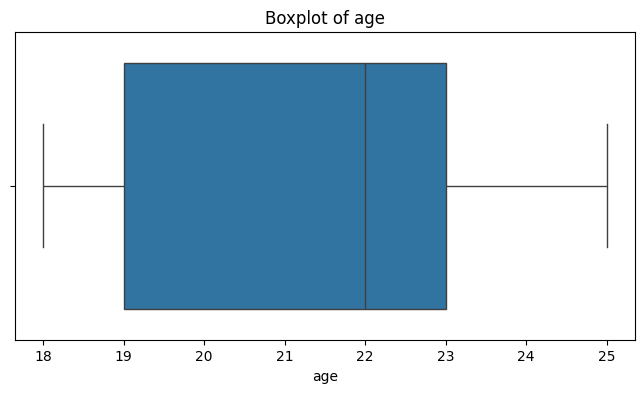

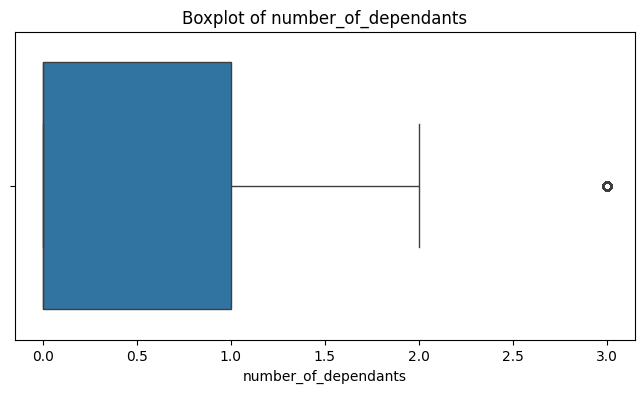

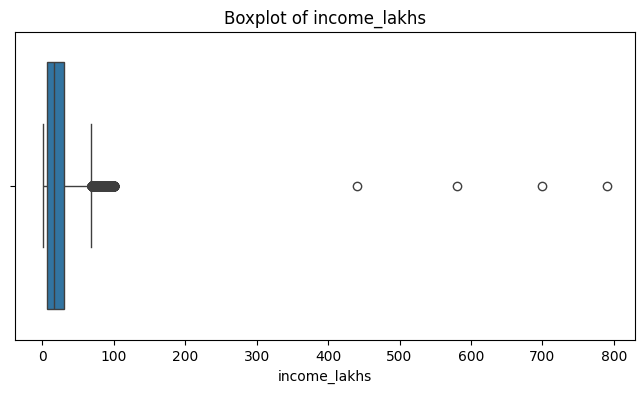

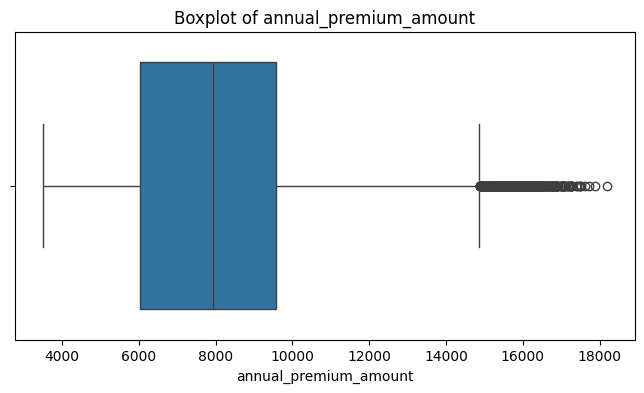

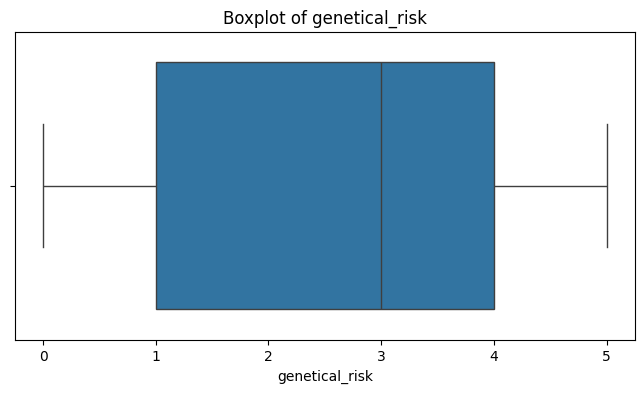

In [104]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Removing outliers of age

In [105]:
df1 = df[df.age<100].copy()

In [106]:
df1.age.describe()

count    20090.000000
mean        21.494375
std          2.294052
min         18.000000
25%         19.000000
50%         22.000000
75%         23.000000
max         25.000000
Name: age, dtype: float64

### An Function for IQR

In [107]:
def get_iqr_bounds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [108]:
get_iqr_bounds(df1['income_lakhs'])

(np.float64(-31.5), np.float64(68.5))

In [109]:
quantile_threshold = df1['income_lakhs'].quantile(0.999)
quantile_threshold

np.float64(100.0)

In [110]:
df2 = df1[df1.income_lakhs <= quantile_threshold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263,2.503883
std,2.294248,0.937238,21.732062,2749.912486,1.710184
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,100.000000,18186.000000,5.000000


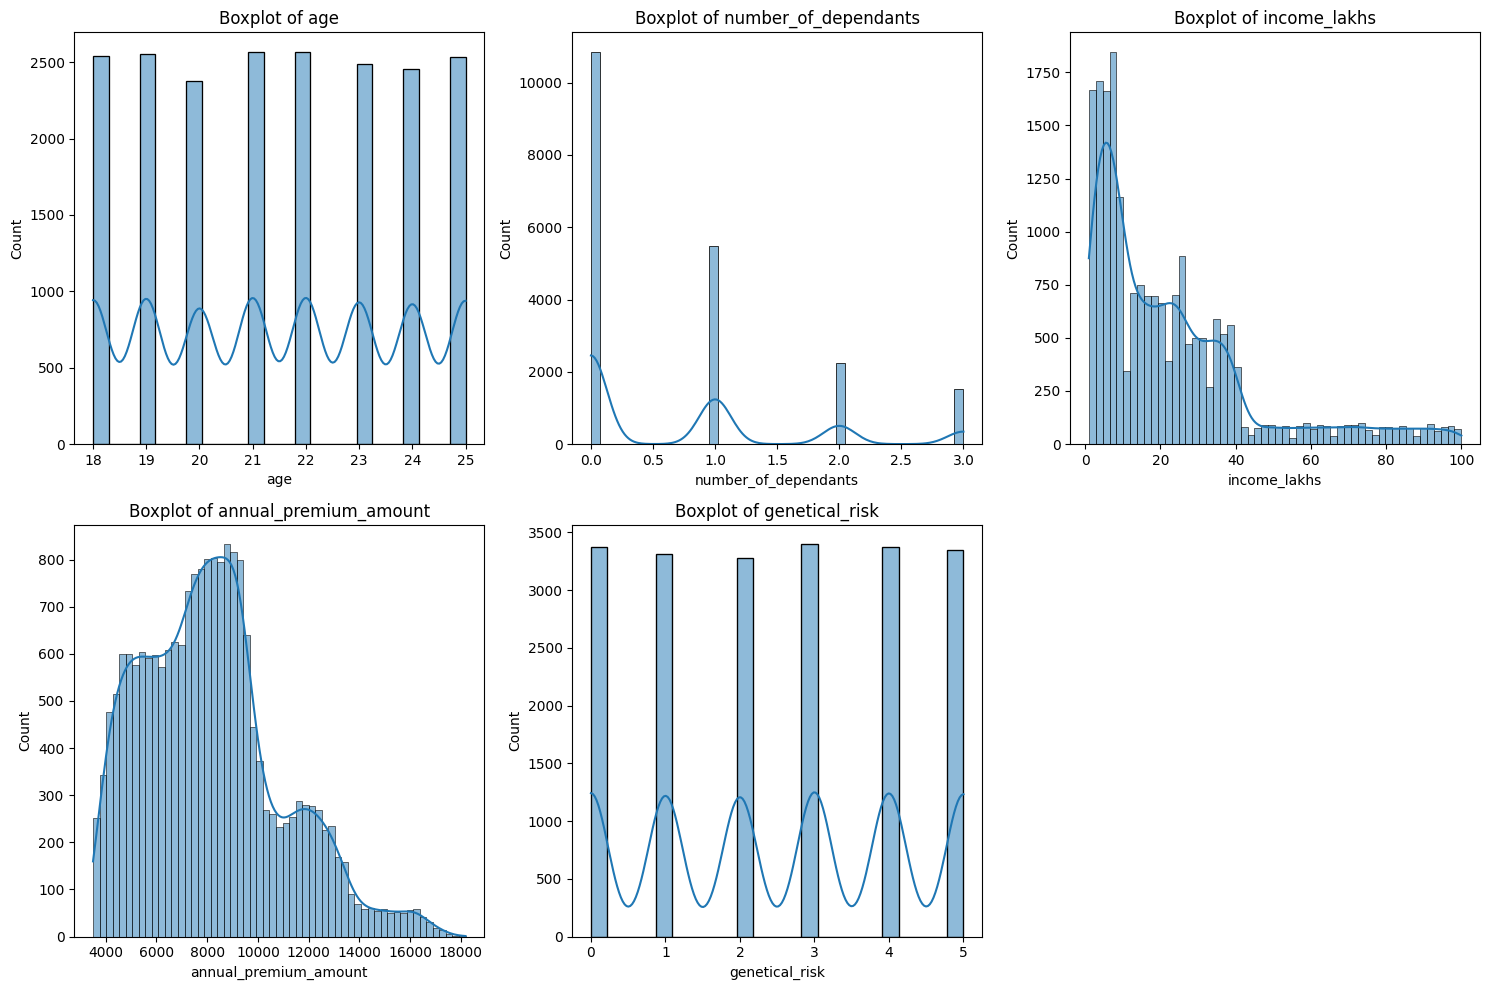

In [111]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

for i,column in enumerate(numeric_columns):
    ax = axes[i // 3, i % 3]
    sns.histplot(x=df2[column], ax=ax, kde=True)
    ax.set_title(f'Boxplot of {column}')
    
if len(numeric_columns) % 3 !=0 :
    for j in range(len(numeric_columns),6):
        axes.flat[j].set_visible(False)
    
plt.tight_layout()
plt.show()

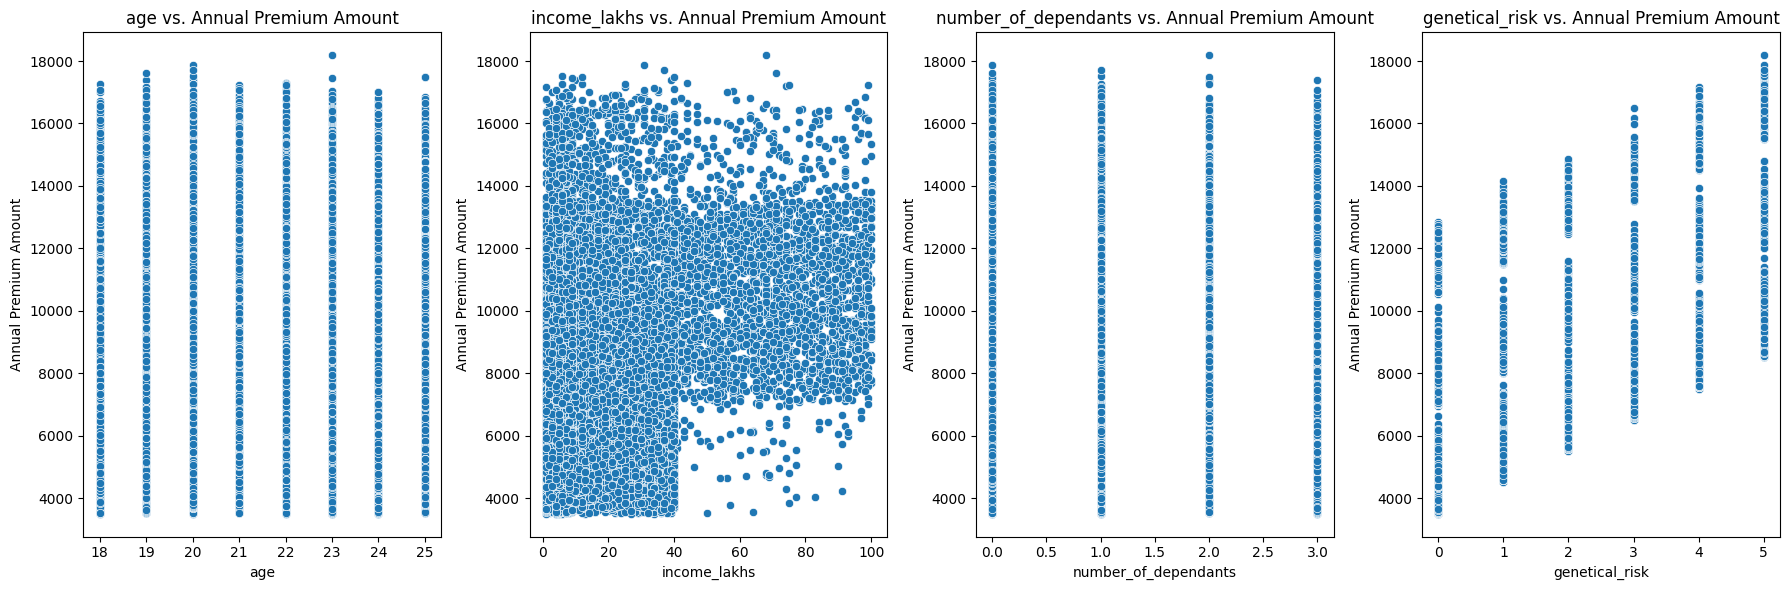

In [112]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants', 'genetical_risk']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()  # Adjust layout
plt.show()

<Axes: xlabel='age', ylabel='annual_premium_amount'>

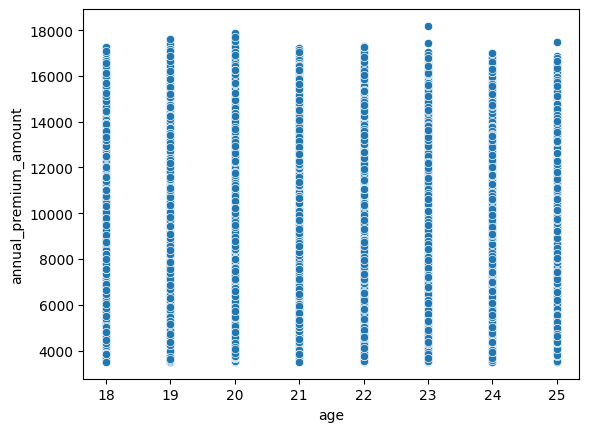

In [113]:
sns.scatterplot(data=df2, x='age', y='annual_premium_amount')

In [114]:
categorical_columns = df2.select_dtypes(include=['object']).columns

C:\Users\ittis\AppData\Local\Temp\ipykernel_10452\1042019130.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df2.select_dtypes(include=['object']).columns


In [115]:
for col in categorical_columns:
    print(f"{col} : {df2[col].unique().tolist()}")

gender : ['Male', 'Female']
region : ['Northeast', 'Northwest', 'Southeast', 'Southwest']
marital_status : ['Unmarried', 'Married']
bmi_category : ['Overweight', 'Underweight', 'Normal', 'Obesity']
smoking_status : ['Regular', 'No Smoking', 'Occasional', 'Smoking=0', 'Does Not Smoke', 'Not Smoking']
employment_status : ['Self-Employed', 'Freelancer', 'Salaried']
income_level : ['> 40L', '<10L', '10L - 25L', '25L - 40L']
medical_history : ['High blood pressure', 'No Disease', 'Diabetes & High blood pressure', 'Diabetes & Heart disease', 'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid', 'High blood pressure & Heart disease']
insurance_plan : ['Silver', 'Bronze', 'Gold']


In [116]:
df2.replace({
    'Not Smoking': 'No Smoking',
    'Smoking=0' : 'No Smoking',
    'Does Not Smoke' : 'No Smoking'
}, inplace=True)

df2['smoking_status'].unique()

<ArrowStringArray>
['Regular', 'No Smoking', 'Occasional']
Length: 3, dtype: str

In [117]:
pct_count = df2['gender'].value_counts(normalize=True)
pct_count

gender
Male      0.550383
Female    0.449617
Name: proportion, dtype: float64

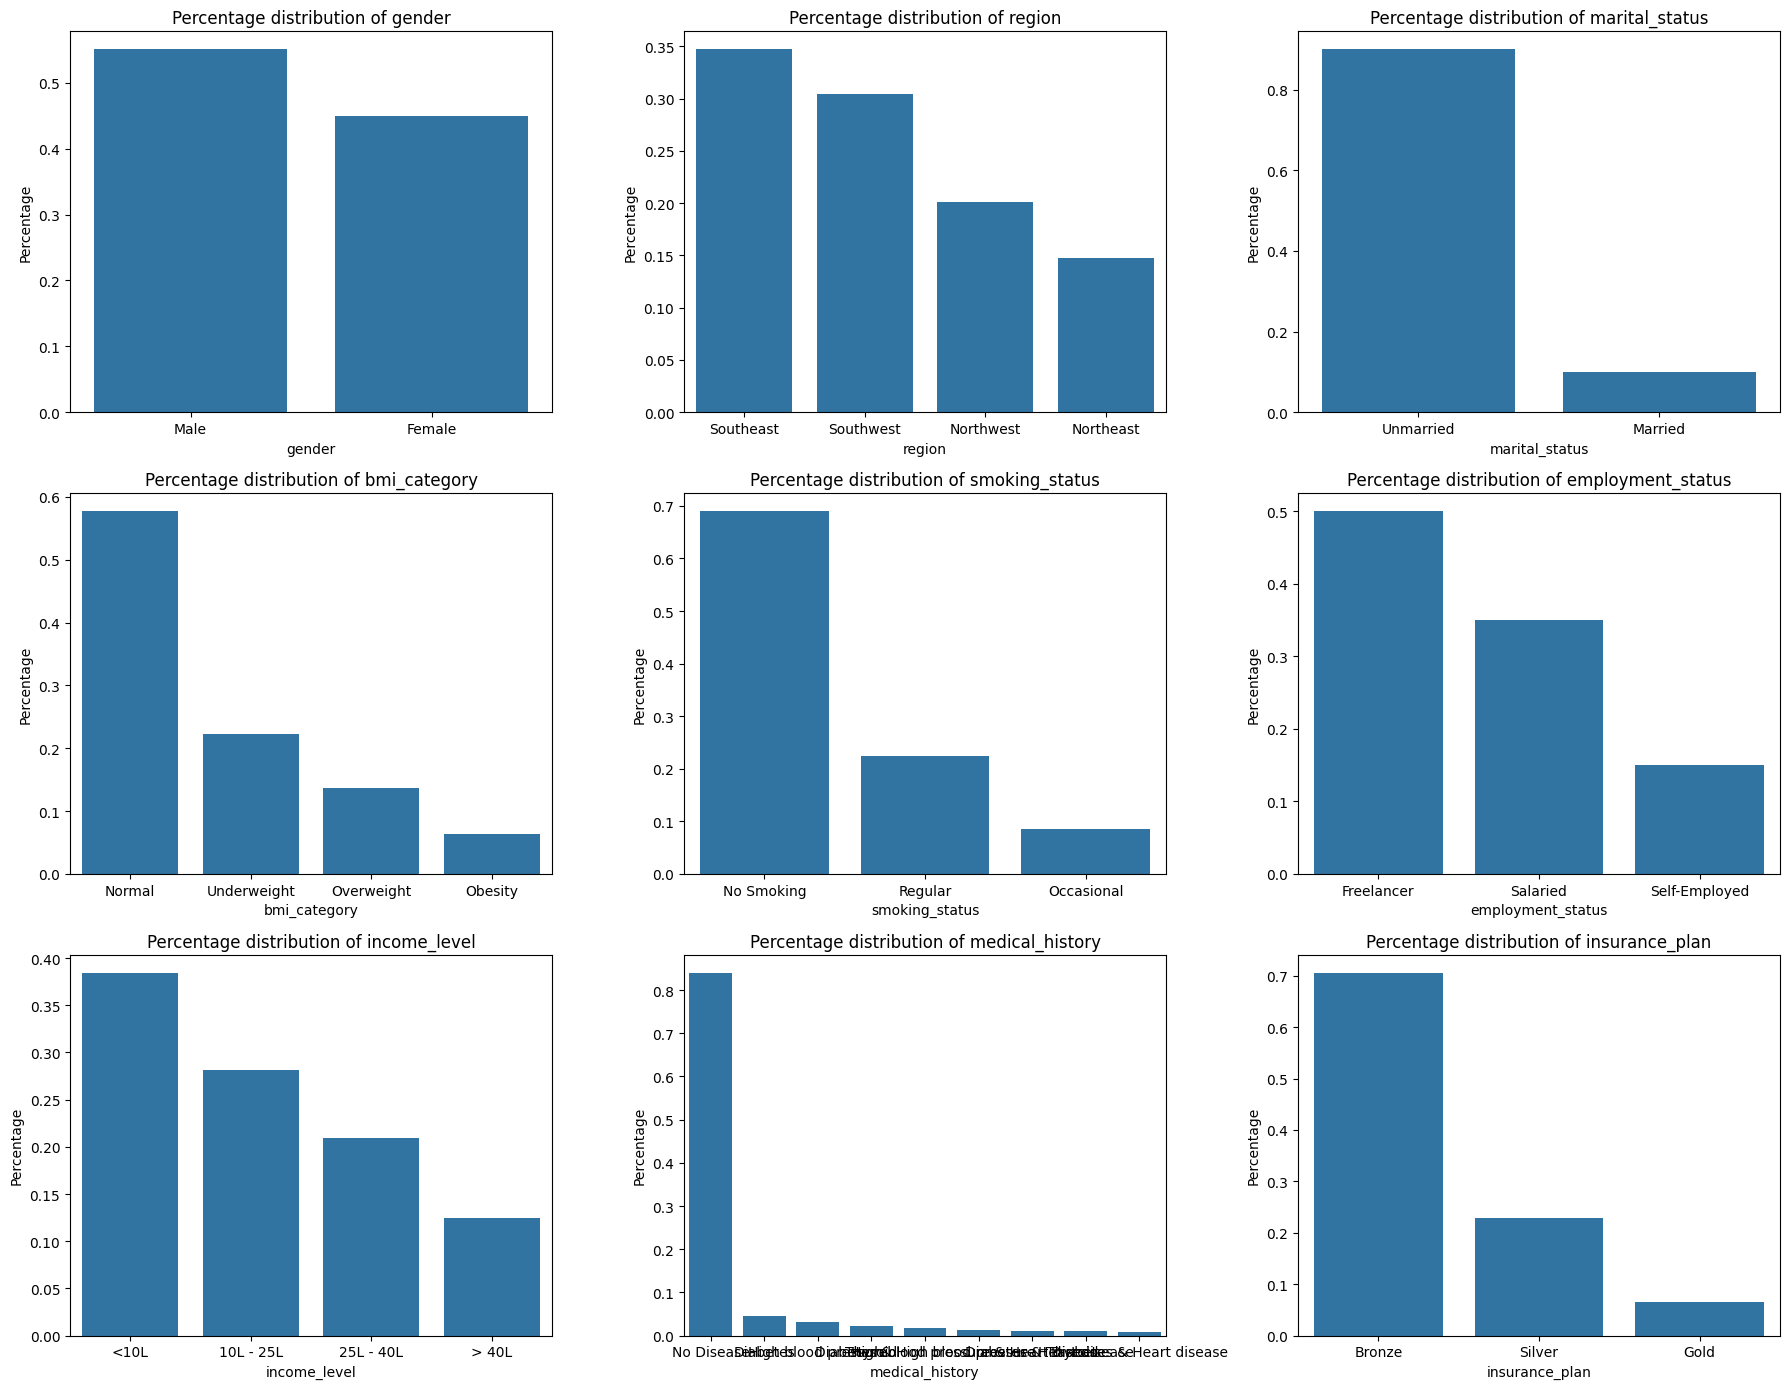

In [118]:
fig, axes = plt.subplots(3,3,figsize=(18, 14))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    category_counts = df2[column].value_counts(normalize=True)
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Percentage')
    
plt.tight_layout()
plt.show()

In [119]:
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,4508,326,828
25L - 40L,3382,209,608
<10L,6172,404,1145
> 40L,115,366,2023


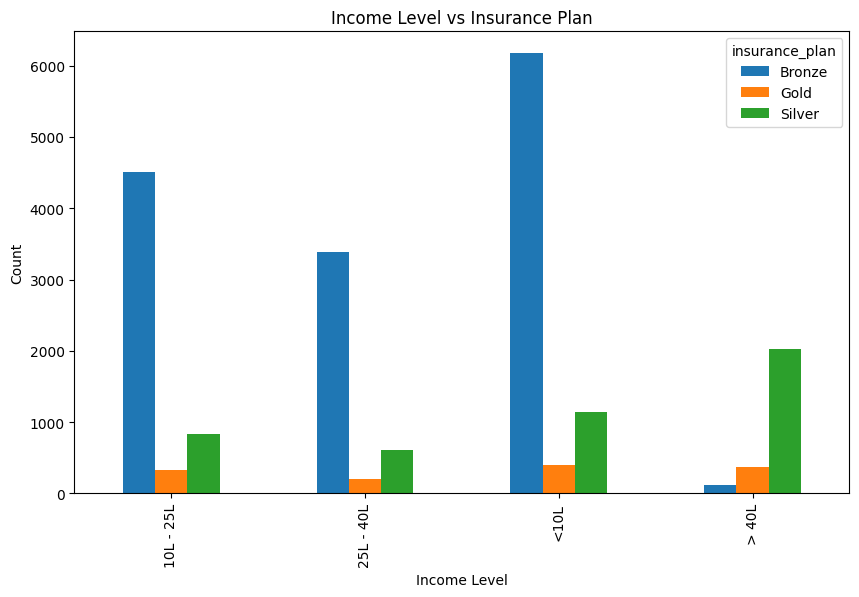

In [120]:
crosstab.plot(kind='bar', figsize=(10, 6))
plt.title('Income Level vs Insurance Plan')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='insurance_plan', ylabel='income_level'>

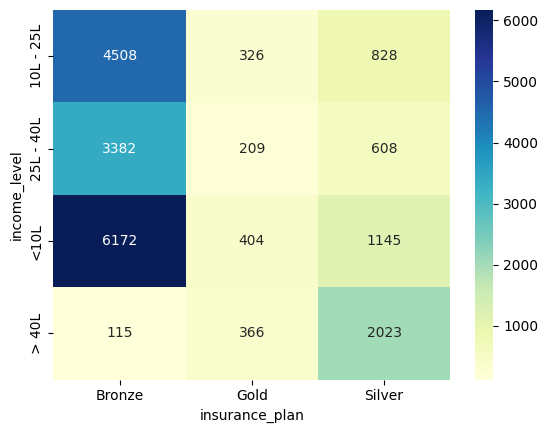

In [121]:
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')

In [122]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3


In [123]:
df2.medical_history.unique()

<ArrowStringArray>
[                'High blood pressure',                          'No Disease',
      'Diabetes & High blood pressure',            'Diabetes & Heart disease',
                            'Diabetes',                  'Diabetes & Thyroid',
                       'Heart disease',                             'Thyroid',
 'High blood pressure & Heart disease']
Length: 9, dtype: str

In [124]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df2[['disease1','disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x : x.str.lower())

In [125]:
df2['disease1'] = df2['disease1'].fillna('none')
df2['disease2'] = df2['disease2'].fillna('none')

df2['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += (
        df2[disease]
        .map(risk_scores)
        .fillna(0)
    )

min_score = df2['total_risk_score'].min()
max_score = df2['total_risk_score'].max()

df2['normalized_risk_score'] = (
    df2['total_risk_score'] - min_score
) / (max_score - min_score)

df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1,no disease,none,0,0.000000


###  Encoding the Categorical columns

In [126]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [127]:
df2.income_level.unique()

<ArrowStringArray>
['> 40L', '<10L', '10L - 25L', '25L - 40L']
Length: 4, dtype: str

In [128]:

df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [129]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,4,high blood pressure,none,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,3,no disease,none,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,4,no disease,none,...,1,0,1,0,0,0,0,1,1,0


In [130]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df4.head(3)                

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,4,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,3,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,4,0.000000,0,0,1,0,1,0,0,0,0,1,1,0


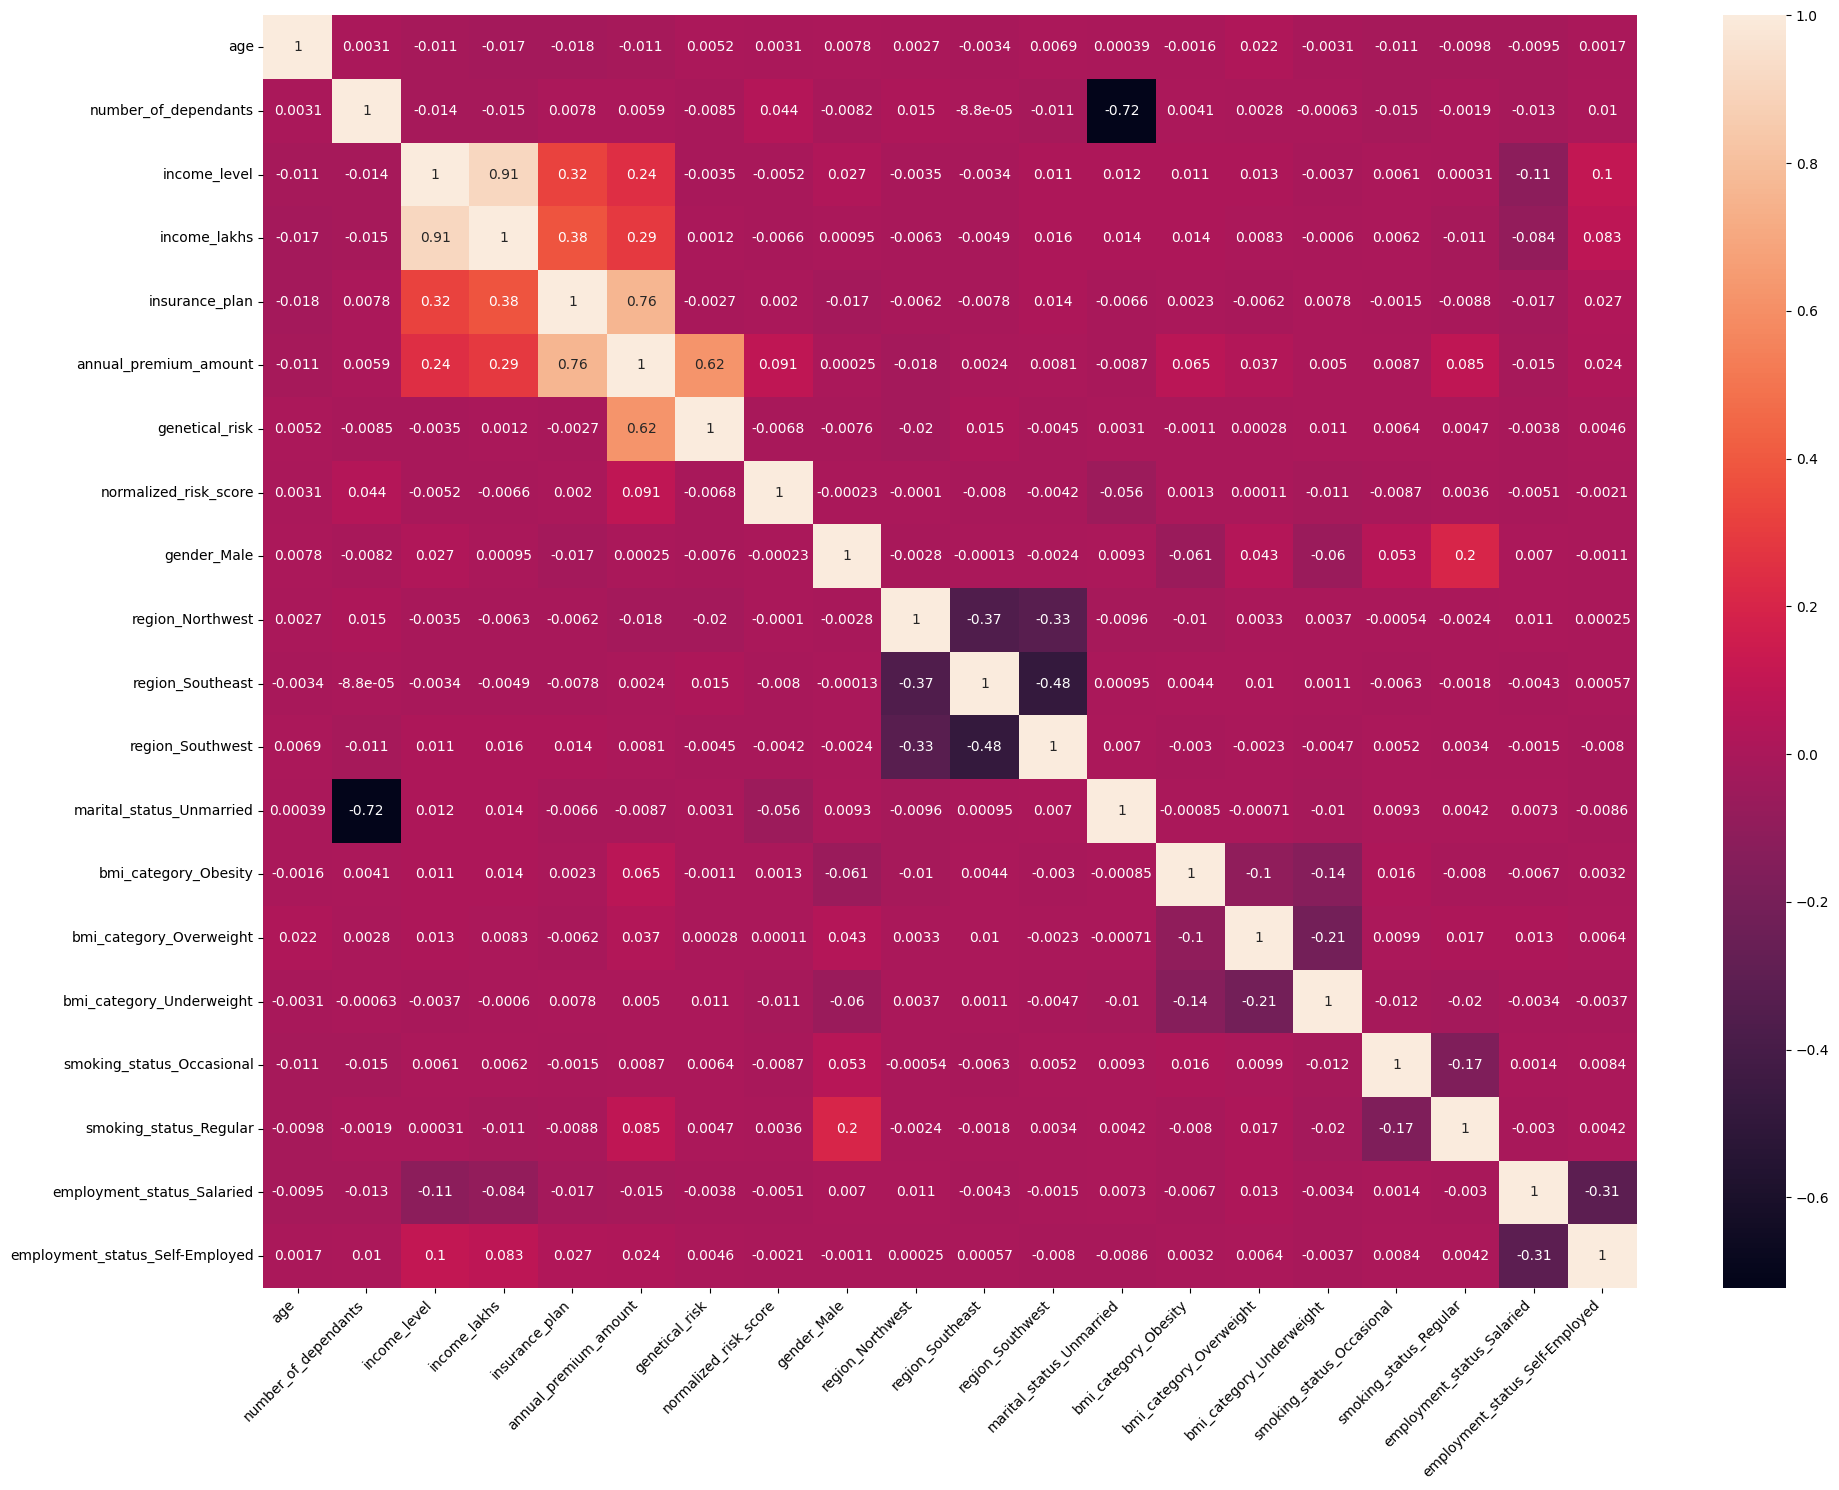

In [131]:
cm = df4.corr()

plt.figure(figsize=(20,15))
sns.heatmap(cm, annot=True)
plt.xticks(rotation = 45 , ha = 'right')
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()


 <h2 align="center" style="color:Yellow">Feature Engineering</h2>

In [132]:
df4.head(7)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,4,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,3,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,4,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,2,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,1,0.000000,1,0,1,0,1,0,1,0,0,0,0,0
5,22,0,3,30,3,15473,3,0.428571,0,0,0,1,1,0,0,1,0,1,0,0
6,19,0,1,8,1,4097,0,0.000000,1,0,0,1,1,0,0,0,0,0,0,0


In [133]:
X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan','genetical_risk']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,0.499211,0.240914,0.357994,0.216064,0.179578,0.500777,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,0.327750,0.312413,0.347481,0.219516,0.300051,0.342037,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.050505,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.333333,0.151515,0.000000,0.600000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.303030,0.500000,0.800000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [134]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [135]:
calculate_vif(X)

,Column,VIF
0,age,1.001682
1,number_of_dependants,2.095176
2,income_level,5.801117
3,income_lakhs,6.032763
4,insurance_plan,1.175333
5,genetical_risk,1.001136
6,normalized_risk_score,1.003845
7,gender_Male,1.064720
8,region_Northwest,1.893214
9,region_Southeast,2.194182


In [136]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,1.001606
1,number_of_dependants,2.095132
2,income_lakhs,1.183555
3,insurance_plan,1.171276
4,genetical_risk,1.001011
5,normalized_risk_score,1.003842
6,gender_Male,1.061173
7,region_Northwest,1.893173
8,region_Southeast,2.194172
9,region_Southwest,2.136623


In [137]:
X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:Yellow">Model Training</h2>

In [138]:
X_train , X_test , y_train , y_test = train_test_split(X_reduced, y , test_size= 0.25, random_state=20)
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (15064, 18)
x test:  (5022, 18)
y train:  (15064,)
y test:  (5022,)


In [139]:
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)
model_lr.score(X_test,y_test)


0.988205640974013

In [140]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  87435.82197440405 RMSE:  295.69548859325545


In [141]:
feature_importance = model_lr.coef_

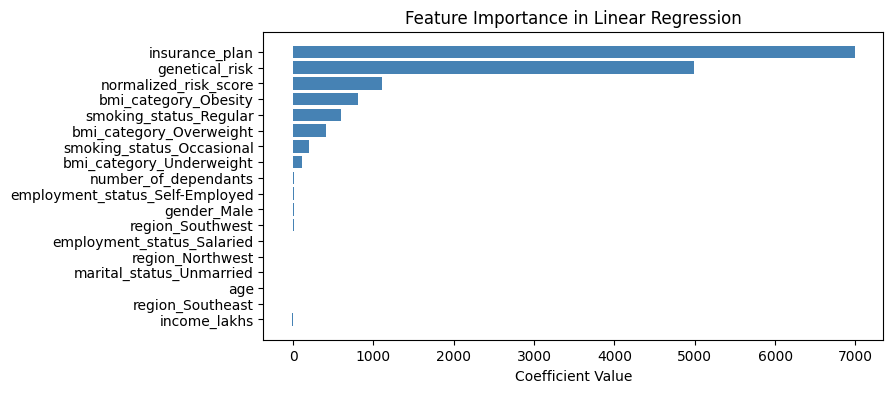

In [142]:

coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])


coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

<h2 align="center" style="color:Yellow">Ridge Regression Model</h2>

In [143]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.988498988847492, 0.9882040580235407)

In [144]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  87447.55695511667 RMSE:  295.71533094365714


<h2 align="center" style="color:Yellow">XGBOOST Regression Model</h2>

In [145]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9870097041130066

In [146]:
y_pred = model_xgb.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  96301.578125 RMSE:  310.32495569161046


In [147]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.9881514509518942)

In [148]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [149]:
best_model = random_search.best_estimator_

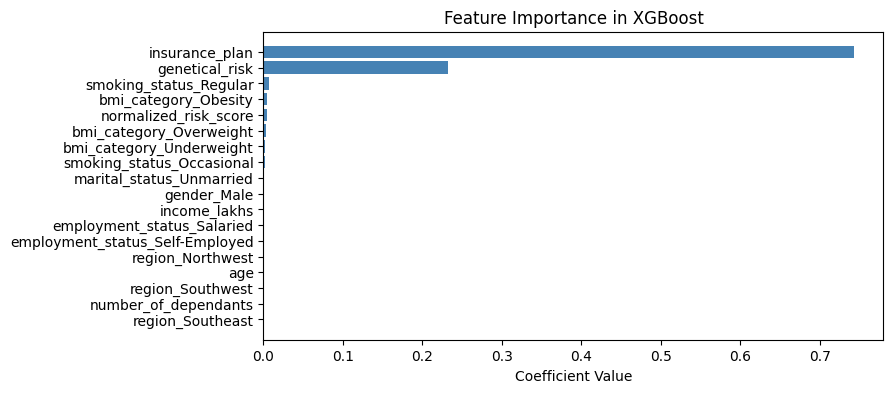

In [150]:
feature_importance = best_model.feature_importances_


coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

<h2 align="center" style="color:Yellow">Error Calculation</h2>

In [151]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = residuals*100/y_test

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
19483,7771,8138.907715,367.907715,4.734368
5375,8193,8065.452148,-127.547852,-1.556791
12632,7181,7415.802246,234.802246,3.269771
5520,6118,6050.988281,-67.011719,-1.095321
7324,12983,13027.183594,44.183594,0.340319


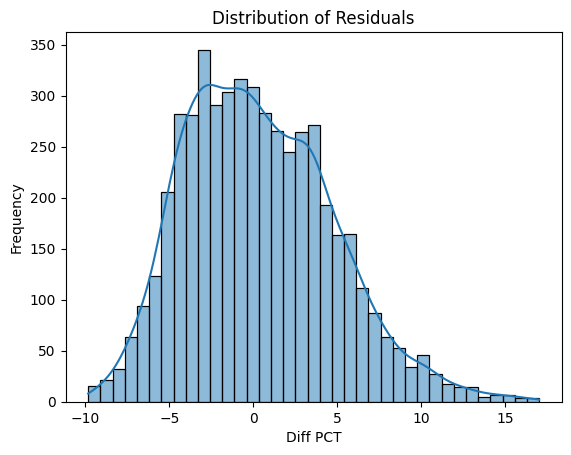

In [152]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [153]:
extreme_error_threshold = 10

extreme_results_df = results_df[np.abs(results_df.diff_pct)> extreme_error_threshold] 
extreme_results_df.shape

(129, 4)

In [154]:
extreme_results_df.shape[0]*100/results_df.shape[0]

2.5686977299880525

In [155]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct


In [156]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
17621,0.571429,0.666667,0.232323,0.0,0.2,0.0,1,1,0,0,1,0,0,0,0,0,1,0
10156,0.142857,0.000000,0.101010,0.0,0.0,0.0,1,0,0,1,1,0,0,0,1,0,1,0
7423,0.142857,1.000000,0.000000,0.0,0.0,0.0,0,0,1,0,0,0,0,0,0,0,0,1
343,0.428571,0.000000,0.353535,0.0,0.0,0.0,0,0,0,1,1,0,0,1,0,0,0,0
19428,0.571429,0.333333,0.333333,0.0,0.0,0.0,0,0,1,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10484,0.142857,0.000000,0.373737,0.0,0.0,0.0,1,0,0,0,1,0,0,1,0,0,0,0
17888,0.285714,0.333333,0.242424,0.0,0.0,0.0,1,1,0,0,1,0,1,0,0,0,0,0
57,0.285714,0.000000,0.000000,0.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,0,1
7912,0.714286,0.333333,0.070707,0.0,0.2,0.0,0,1,0,0,1,0,0,0,0,0,0,0


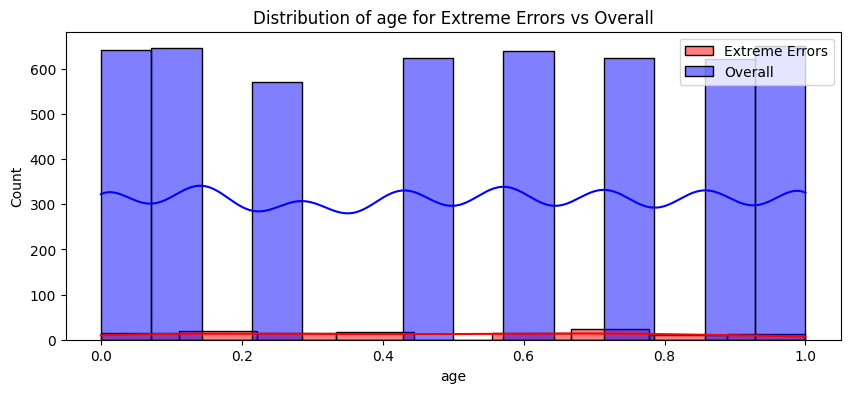

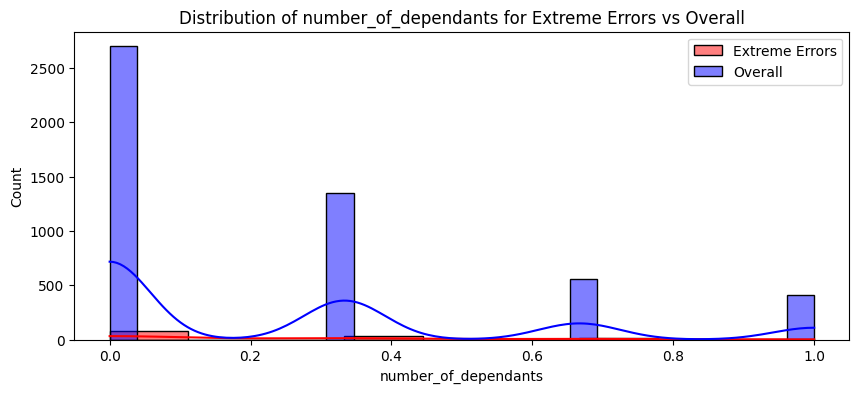

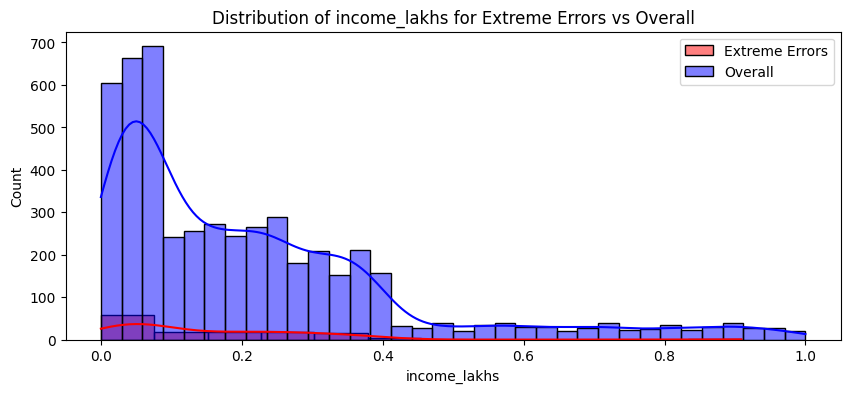

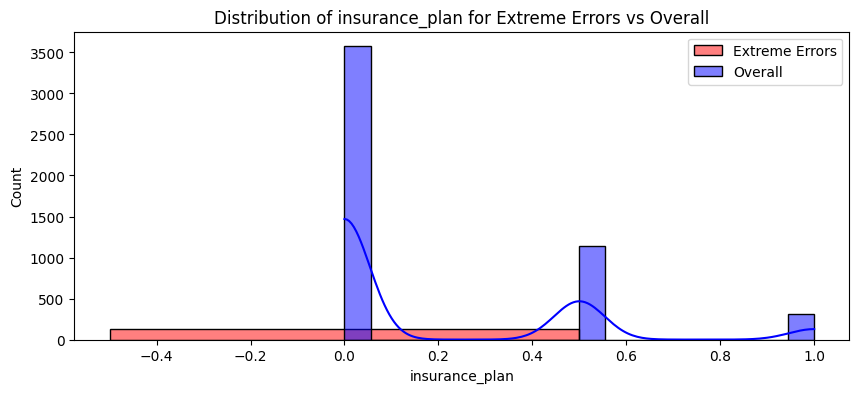

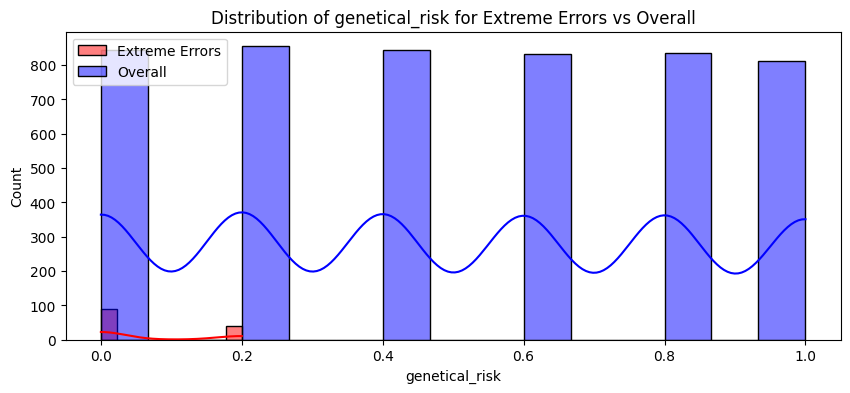

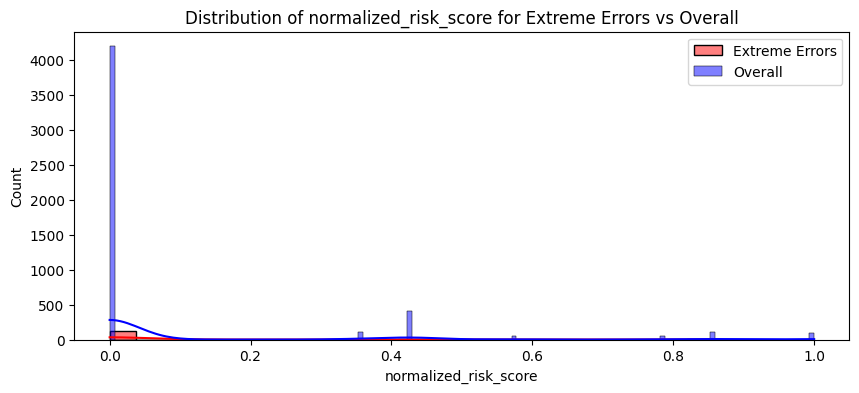

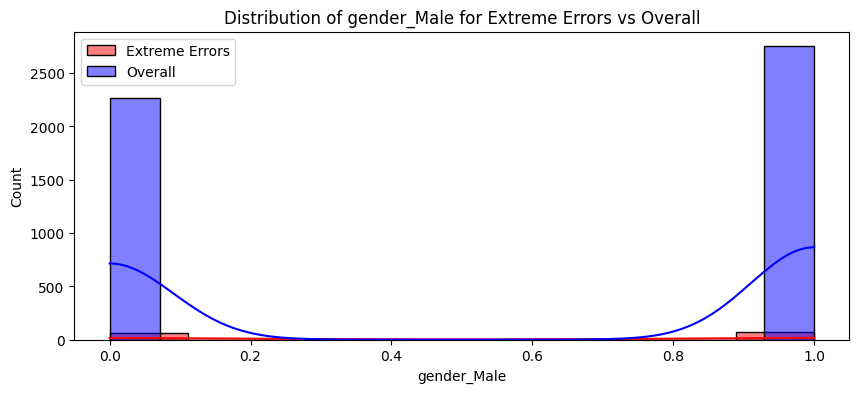

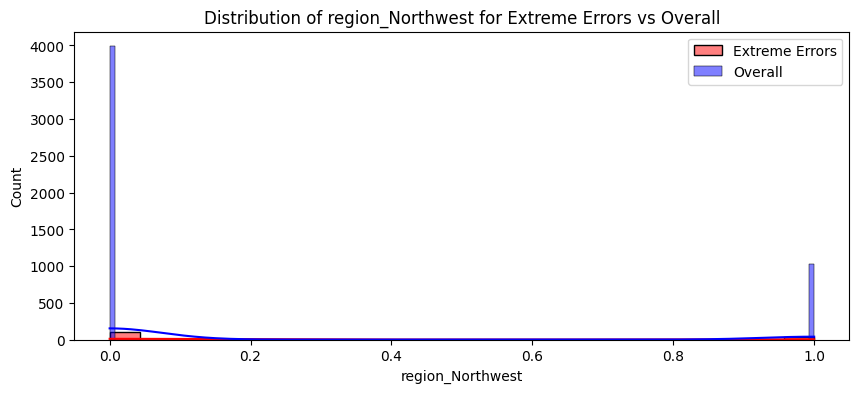

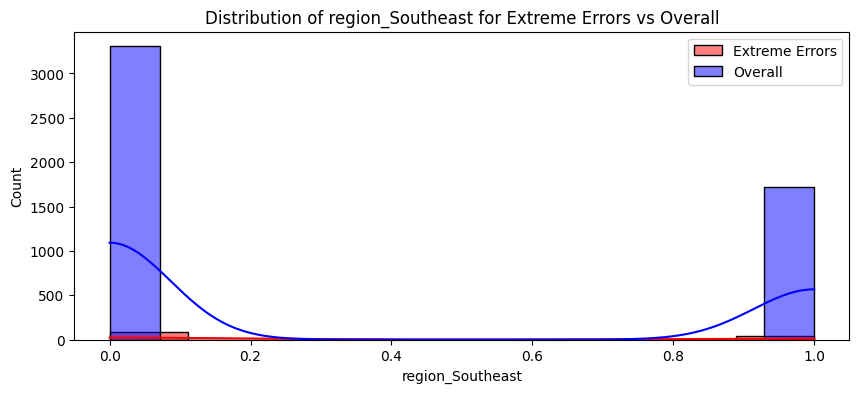

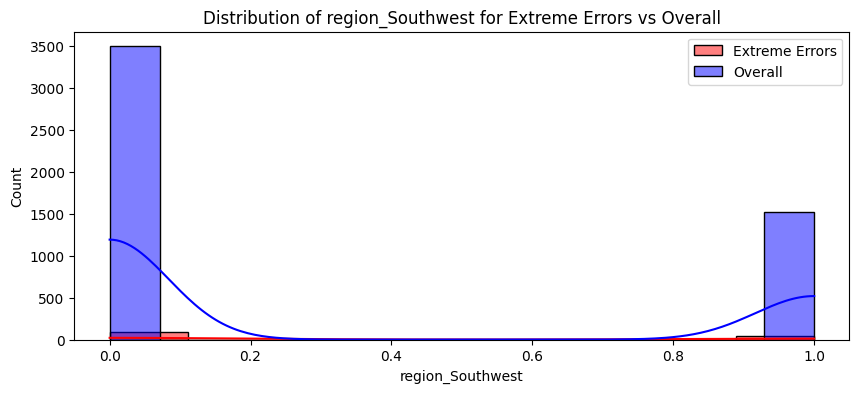

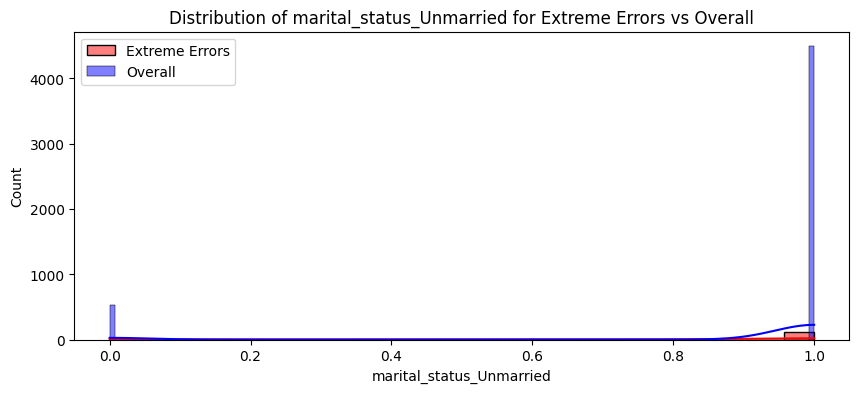

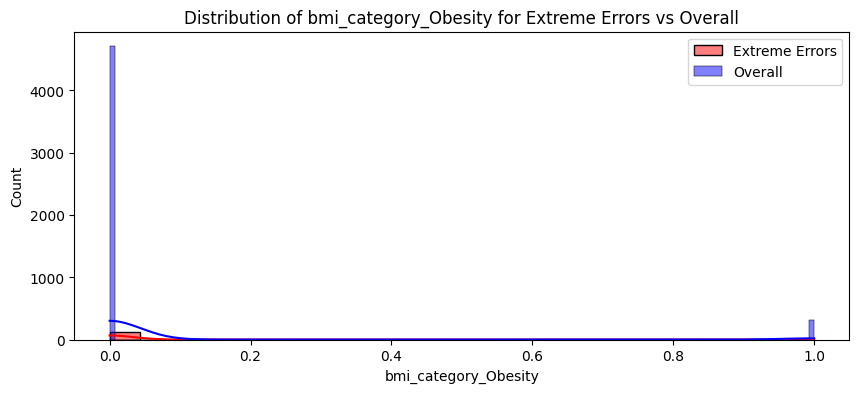

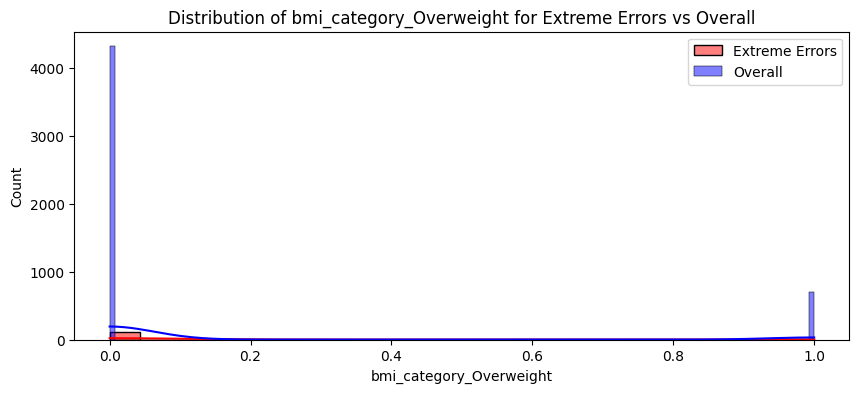

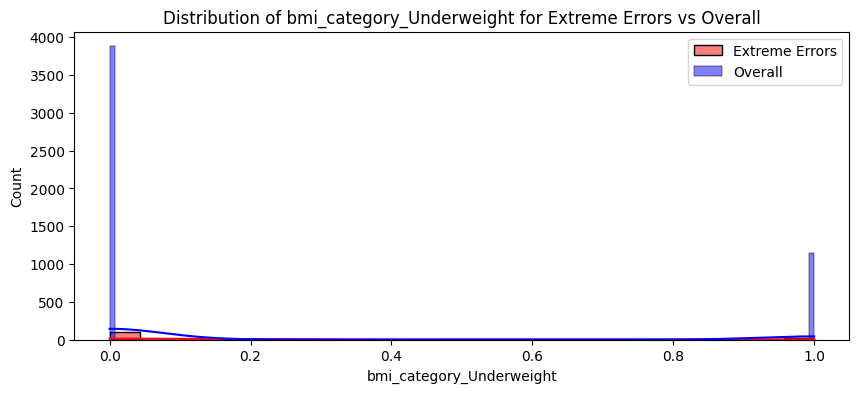

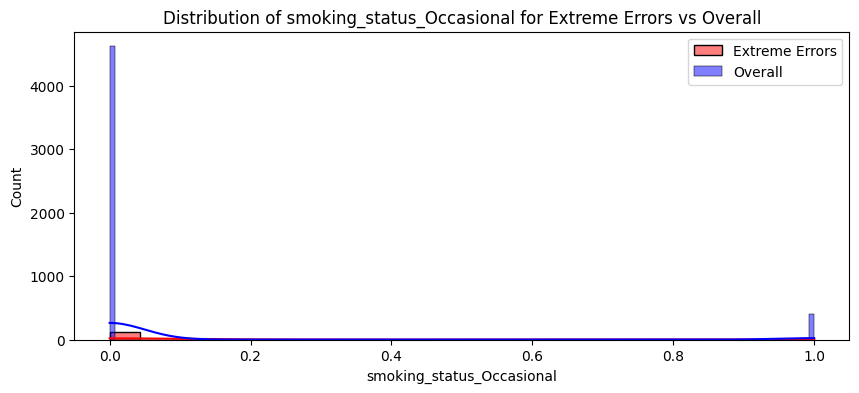

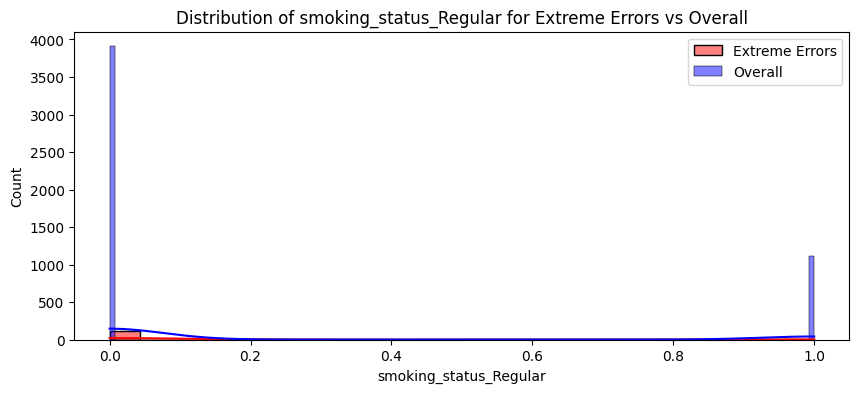

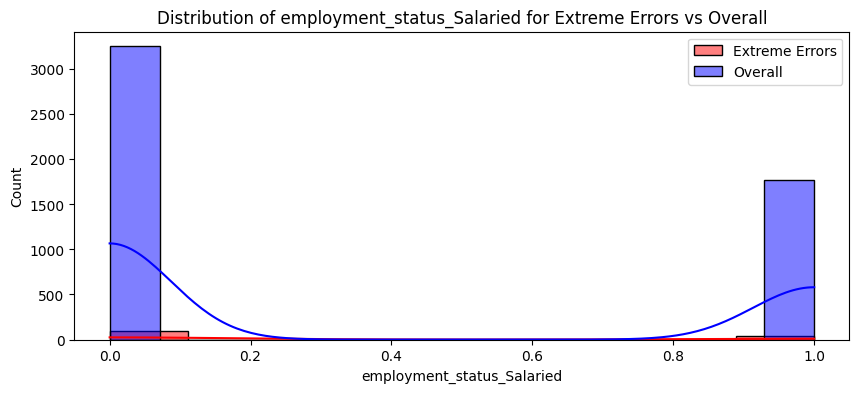

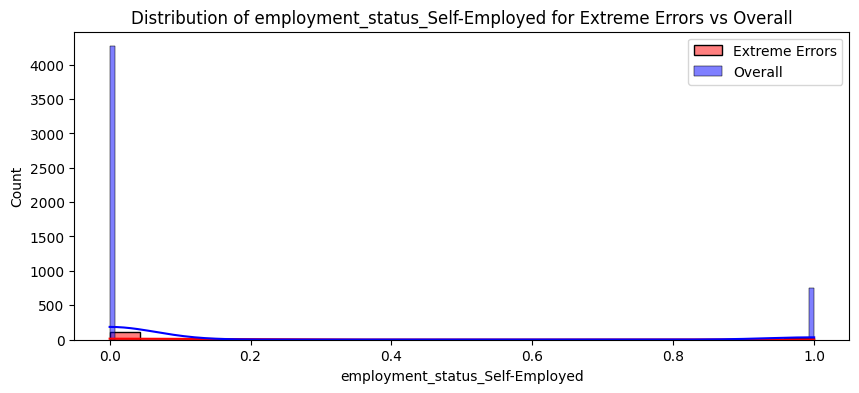

In [157]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

# reverse scaling

In [158]:
extreme_errors_df['income_level']=-1

In [159]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk
0,22.0,2.0,-2.0,24.0,1.0,1.0
1,19.0,0.0,-2.0,11.0,1.0,0.0
2,19.0,3.0,-2.0,1.0,1.0,0.0
3,21.0,0.0,-2.0,36.0,1.0,0.0
4,22.0,1.0,-2.0,34.0,1.0,0.0


In [160]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk
count,129.000000,129.000000,129.0,129.000000,129.0,129.000000
mean,21.325581,0.604651,-2.0,15.775194,1.0,0.317829
std,2.233141,0.851640,0.0,13.248962,0.0,0.467448
min,18.000000,0.000000,-2.0,1.000000,1.0,0.000000
25%,19.000000,0.000000,-2.0,5.000000,1.0,0.000000
50%,21.000000,0.000000,-2.0,11.000000,1.0,0.000000
75%,23.000000,1.000000,-2.0,25.000000,1.0,1.000000
max,25.000000,3.000000,-2.0,91.000000,1.0,1.000000


<Axes: xlabel='age', ylabel='Count'>

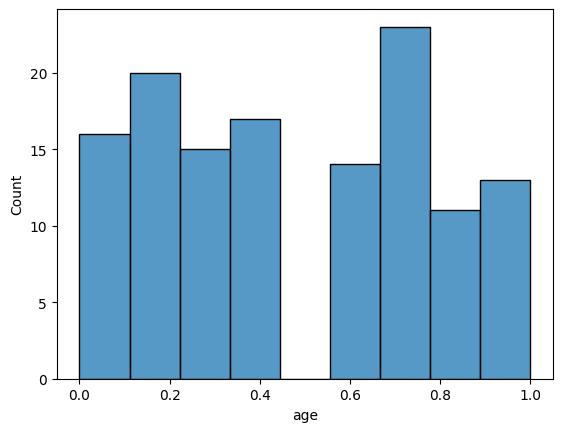

In [161]:
sns.histplot(extreme_errors_df.age)

<Axes: xlabel='age', ylabel='Count'>

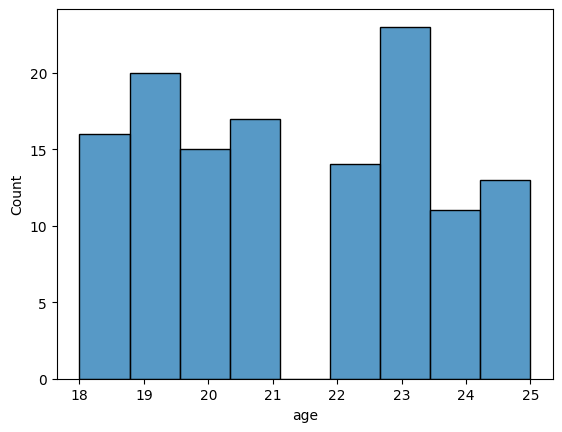

In [162]:
sns.histplot(df_reversed.age)

In [163]:
from joblib import dump

dump(best_model,"Artifacts/model_young.joblib")

scaler_with_cols = {
    'scaler': scaler , 
    'cols_to_scale': cols_to_scale
}

dump(scaler_with_cols,"Artifacts/scaler_young.joblib")

['Artifacts/scaler_young.joblib']